In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Failed to load image Python extension"
)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

#import torchvision
from torchvision import models
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

from models.covidnet import CovidNet
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Opération terminée")

Opération terminée


1. Chargement des images

In [2]:
chemin="/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_split"

def display_directory_structure_limited(root_dir, max_files=3):
    for root, dirs, files in os.walk(root_dir):
        level = root.replace(root_dir, '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/")
        sub_indent = ' ' * 4 * (level + 1)
        for i, f in enumerate(files):
            if i < max_files:
                print(f"{sub_indent}{f}")
            else:
                print(f"{sub_indent}...")
                break


print(display_directory_structure_limited(chemin))



COVID-19_Radiography_Dataset_split/
    .DS_Store
    test/
        .DS_Store
        Viral Pneumonia/
            Viral Pneumonia-770.png
            Viral Pneumonia-599.png
            Viral Pneumonia-15.png
            ...
        Lung_Opacity/
            Lung_Opacity-3111.png
            Lung_Opacity-2233.png
            Lung_Opacity-1048.png
            ...
        Normal/
            Normal-1821.png
            Normal-3788.png
            Normal-950.png
            ...
        COVID/
            COVID-790.png
            COVID-1405.png
            COVID-2642.png
            ...
    train/
        Viral Pneumonia/
            Viral Pneumonia-1186.png
            Viral Pneumonia-764.png
            Viral Pneumonia-994.png
            ...
        Lung_Opacity/
            Lung_Opacity-129.png
            Lung_Opacity-1060.png
            Lung_Opacity-2569.png
            ...
        Normal/
            Normal-6196.png
            Normal-7288.png
            Normal-4781.png
        

Calcul de la moyenne et de l'écart-type des images

In [3]:
transform_stats=transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_set_stat=datasets.ImageFolder(chemin+"/train_augmented", transform_stats)

train_loader_stats=DataLoader(train_set_stat, batch_size=32, shuffle=False)

In [4]:
n_pixels = 0
sum_pixels = 0.0
sum_squared_pixels = 0.0

for images, _ in train_loader_stats:

    images = images.float()

    n_pixels += images.numel()

    sum_pixels += images.sum()

    sum_squared_pixels += (images ** 2).sum()

mean = sum_pixels / n_pixels
std = torch.sqrt(sum_squared_pixels / n_pixels - mean ** 2)

print(f"Moyenne des pixels : {mean.item():.6f}")
print(f"Écart-type  : {std.item():.6f}")

Moyenne des pixels : 0.163942
Écart-type  : 0.242781


Chargement des images du jeu de données en vue de l'entraînement du modèle

In [5]:
transform=transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
   transforms.Normalize(
   mean=[mean],
    std=[std]
)
])

train_set=datasets.ImageFolder(chemin+"/train_augmented", transform=transform)
test_set=datasets.ImageFolder(chemin+"/test", transform=transform)
val_set=datasets.ImageFolder(chemin+"/validation", transform=transform)

train_loader=DataLoader(train_set, batch_size=32, shuffle=True, num_workers=4)
test_loader=DataLoader(test_set, batch_size=32, shuffle=True, num_workers=4)
val_loader=DataLoader(val_set, batch_size=32, shuffle=True, num_workers=4)

In [6]:
print(train_set.class_to_idx)

{'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}


2. Visualisation du jeu de données

Shape X : torch.Size([32, 1, 224, 224])
Shape y : torch.Size([32])
Moyenne : -0.0063
Écart-type : 0.9961


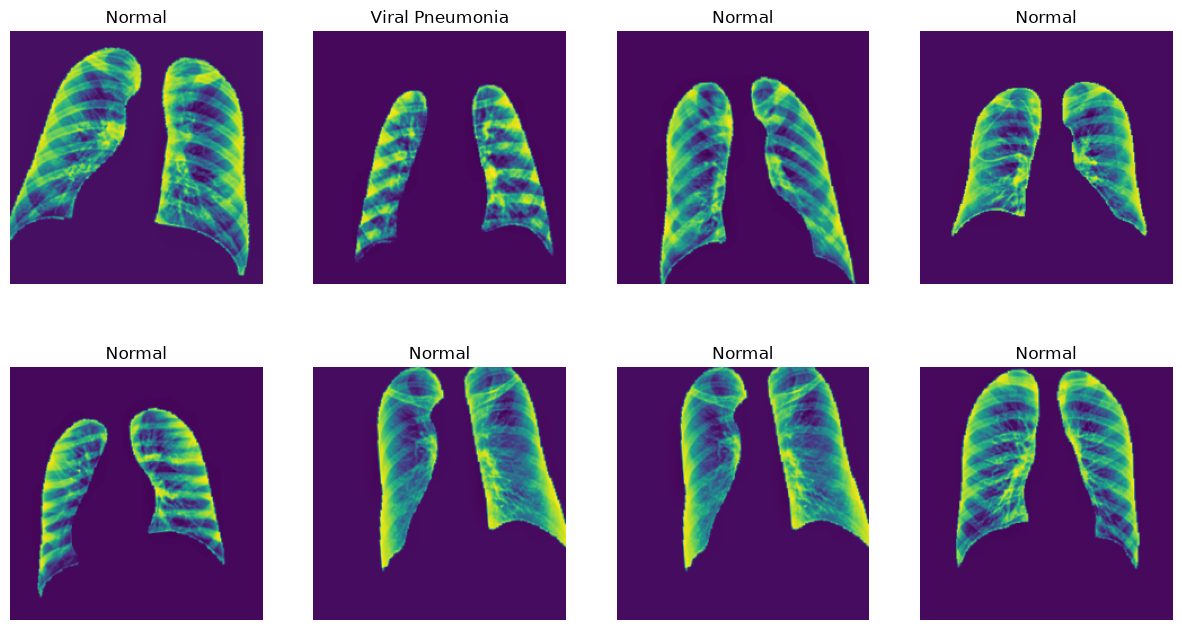

In [7]:
X_t, y_t = next(iter(train_loader))
print(f"Shape X : {X_t.shape}")
print(f"Shape y : {y_t.shape}")
print(f"Moyenne : {X_t.mean():.4f}")
print(f"Écart-type : {X_t.std():.4f}")
plt.figure(figsize=(15,8))
j=1
for i in np.random.randint(0, len(X_t), size=[8]):
    plt.subplot(2,4,j)
    plt.axis('off')
    im = X_t[i].permute(1, 2, 0)
    im = (im - im.min())/(im.max()-im.min())
    plt.imshow(im)
    plt.title(train_set.classes[y_t[i].item()])
    j+=1

3. Chargement du modèle

In [8]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
   device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)


mps


In [9]:
model = CovidNet(num_classes=4).to(device)
model

CovidNet(
  (stem): Stem(
    (stem): Sequential(
      (0): ConvBNReLU(
        (block): Sequential(
          (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
        )
      )
      (1): ConvBNReLU(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
        )
      )
      (2): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
  )
  (stage1): Sequential(
    (0): ResidualPEPX(
      (pepx): PEPX(
        (pepx): Sequential(
          (0): PointwiseConv(
            (block): ConvBNReLU(
              (block): Sequential(
                (0): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (1)

In [10]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Nombre de paramètres : {total_params:,}")
print(f"Paramètres entraînables : {trainable_params:,}")

Nombre de paramètres : 2,386,148
Paramètres entraînables : 2,386,148


4. Définition de la fonction de perte

In [11]:

criterion=nn.CrossEntropyLoss()


#Test de la fonction de perte

X_batch, y_batch = next(iter(train_loader))

X_batch=X_batch.to(device)
y_batch=y_batch.to(device)

y_pred=model(X_batch)

print(criterion(y_pred, y_batch))

tensor(1.5204, device='mps:0', grad_fn=<NllLossBackward0>)


5. Définition de l'optimizer

In [14]:
optimizer=optim.Adam(model.parameters(), 1e-3)

6. Mise en place d'un scheduler et d'un historique

In [12]:
history = {

    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "precision": [],
    "recall": [],
    "f1": [],

    "lr": []

}

In [15]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                       mode="min",
                                                       factor=0.5,
                                                       patience=2,
                                                       min_lr=1e-6
                                                      )

In [16]:
#Pour le Early stopping

best_loss = float("inf")
best_f1 = 0.0
patience = 5
counter = 0

7. Création d'une fonction d'évaluation

In [17]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0

    y_true = []
    y_pred = []

    with torch.no_grad():

        for X, y in loader:

            X = X.to(device)
            y = y.to(device)

            outputs = model(X)

            loss = criterion(outputs, y)

            running_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    loss = running_loss / len(loader)

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {"loss":loss, "accuracy":accuracy, "precision":precision, "recall":recall, "f1":f1, "y_true":y_true, "y_pred":y_pred}

7. Entraînement du modèle

In [19]:
epochs=20

torch.autograd.set_detect_anomaly(True)

best_accuracy = 0

for iterations in range (epochs):
    model.train()

    loss_total=0
    correct=0
    total=0

    progress_bar = tqdm(
            train_loader, desc="Epoch {:1d}".format(iterations), leave=True, disable=False
        )
    for i, batch in enumerate(progress_bar):
        X_batch, y_batch=batch

        X_batch=X_batch.to(device)
        y_batch=y_batch.to(device)

        optimizer.zero_grad()
        
        sorties=model(X_batch)

        loss=criterion(sorties, y_batch)
        loss.backward()

        loss_total= loss_total + loss.item()

        predictions = torch.argmax(sorties, dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)
        train_accuracy = correct / total

        optimizer.step()

        progress_bar.set_postfix(
            {
                "training_loss": "{:.3f}".format(loss_total/(i+1)),
                "acc": "{:.3f}".format(train_accuracy)
            })

    val_metrics=evaluate(model, test_loader, criterion, device)
    
    scheduler.step(val_metrics["loss"])
    
    history["train_loss"].append(loss_total / len (train_loader))
    history["val_loss"].append(val_metrics["loss"])
    history["train_acc"].append(train_accuracy)
    history["val_acc"].append(val_metrics["accuracy"])
    history["precision"].append(val_metrics["precision"])
    history["recall"].append(val_metrics["recall"])
    history["f1"].append(val_metrics["f1"])
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if val_metrics["loss"] < best_loss:
        best_loss = val_metrics["loss"]
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

    if val_metrics["f1"] > best_f1:
        best_f1 = val_metrics["f1"]
        torch.save({
            "epoch": iterations + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_f1": best_f1,
            "history": history},"Covidnet.pth")
        print("✔ Modèle sauvegardé")
    
    print(f"Epoch : {iterations + 1}, Loss : {val_metrics['loss']:.4f}, train_accuracy : {val_metrics['accuracy']}")



Epoch 0: 100%|█| 1042/1042 [15:09<00:00,  1.15it/s, training_loss=0.640, acc=0.


✔ Modèle sauvegardé
Epoch : 1, Loss : 0.5677, train_accuracy : 0.7859884836852208


Epoch 1: 100%|█| 1042/1042 [15:07<00:00,  1.15it/s, training_loss=0.505, acc=0.


✔ Modèle sauvegardé
Epoch : 2, Loss : 0.4415, train_accuracy : 0.8392514395393474


Epoch 2: 100%|█| 1042/1042 [15:05<00:00,  1.15it/s, training_loss=0.450, acc=0.


...

Epoch : 16, Loss : 0.4807, train_accuracy : 0.8421305182341651


Epoch 16: 100%|█| 1042/1042 [14:45<00:00,  1.18it/s, training_loss=0.071, acc=0


Epoch : 17, Loss : 0.4191, train_accuracy : 0.8915547024952015


Epoch 17: 100%|█| 1042/1042 [15:26<00:00,  1.12it/s, training_loss=0.045, acc=0


Early stopping


7. Évaluation du modèle sur l'ensemble de test

In [21]:


metrics=evaluate(model, val_loader, criterion, device)


print(f"Loss: {metrics['loss']}")
print(f"Accuracy : {metrics['accuracy']}")
print(f"Precision : {metrics['precision']}")
print(f"recall : {metrics['recall']}")
print(f"f1 : {metrics['f1']}")


Loss: 0.5628392886508002
Accuracy : 0.8785405664906385
Precision : 0.8790096689048893
recall : 0.8785405664906385
f1 : 0.878535313920064


Classes prédites,0,1,2,3
Classes réelles,,,,
0,280,25,30,3
1,49,495,51,3
2,26,52,927,8
3,0,1,5,128


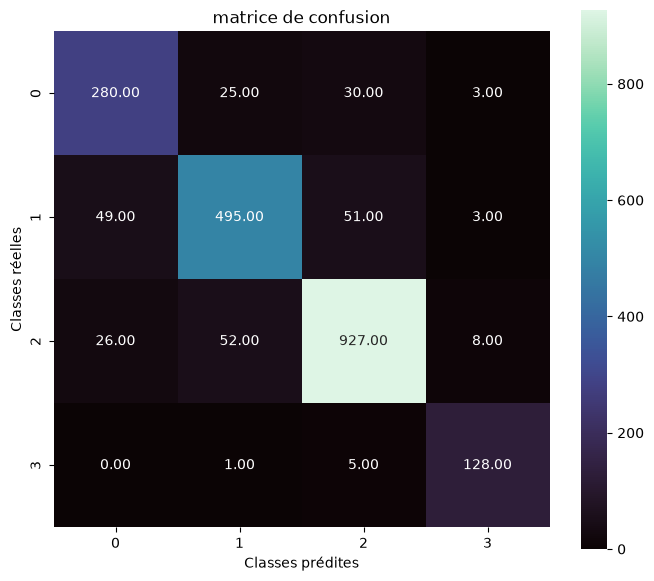

In [23]:
cm=pd.crosstab(metrics["y_true"], metrics["y_pred"], colnames=["Classes prédites"], rownames=["Classes réelles"])
display(cm)

figure_1=plt.figure(figsize=(8,7))

sns.heatmap(cm, annot=True, square=True, fmt=".2f", cmap="mako")

plt.title("matrice de confusion")

plt.show()

In [ ]:
model.eval()
    with torch.no_grad():
    
    

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_accuracy)
    history["precision"].append(val_precision)
    history["recall"].append(val_recall)
    history["f1"].append(val_f1)
    history["lr"].append(

    optimizer.param_groups[0]["lr"]

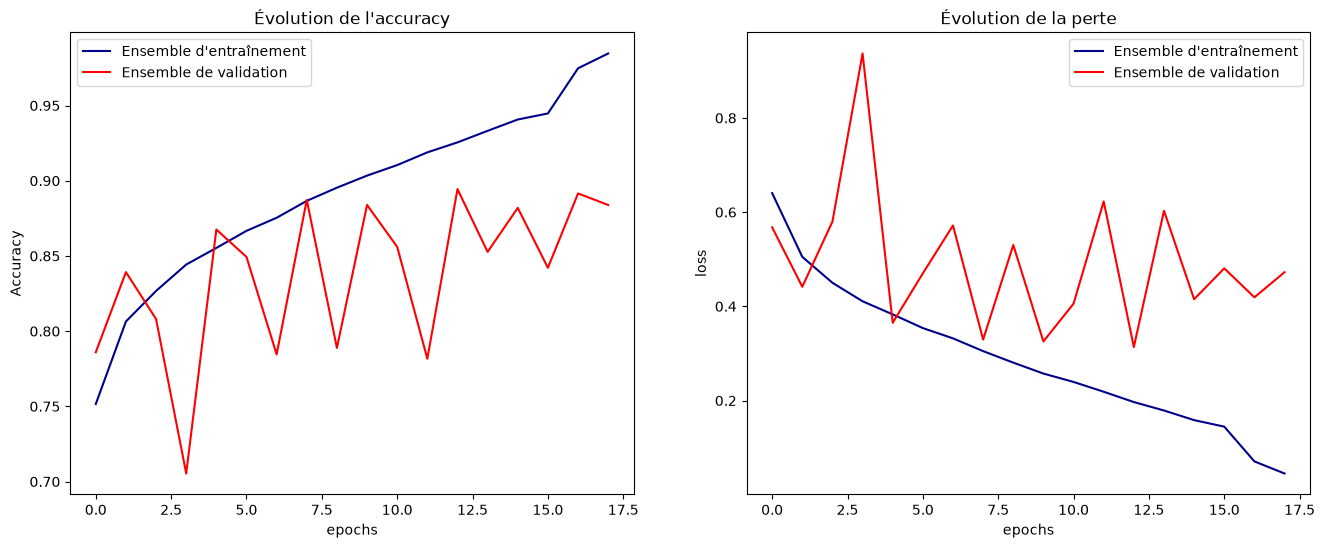

In [36]:
epochs=len(history["train_acc"])

fig=plt.figure(figsize=(16,6))

ax1=plt.subplot(1,2,1)

ax1.plot(np.arange(epochs), history["train_acc"], color="darkblue", label="Ensemble d'entraînement")
ax1.plot(np.arange(epochs), history["val_acc"], color="red", label="Ensemble de validation")

plt.xlabel("epochs")
plt.ylabel("Accuracy")
plt.title("Évolution de l'accuracy")
plt.legend()

ax2=plt.subplot(1,2,2)

ax2.plot(np.arange(epochs), history["train_loss"], color="darkblue", label="Ensemble d'entraînement")
ax2.plot(np.arange(epochs), history["val_loss"], color="red", label="Ensemble de validation")

plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Évolution de la perte")
plt.legend()

plt.show()